<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_04/assignments/assignment_04_combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT_SCI 465: Advanced Electron Microscopy & Diffraction
## Week 03 & 04 Combined Assignment
**Classical, ML, and Deep Learning Approaches to Microscopy Analysis**

**Dataset:** DOPAD (Dataset Of nanoPArticle Detection) - TEM nanoparticle images for detection and classification  
**Dataset Source:** https://dopad.github.io/

## Objective
Compare classical computer vision, machine learning, and deep learning approaches on the same electron microscopy dataset. Progress from traditional image processing through supervised and unsupervised learning to modern deep learning, enabling direct quantitative comparison of all methods.

## Task 1 · Classical Image Analysis Pipeline
- [ ] Apply noise reduction (Gaussian, median, or FFT filtering) and compute signal-to-noise ratio before and after using $SNR = u / igma$.
- [ ] Enhance contrast via histogram equalization or CLAHE (clip limit 0.01-0.03).
- [ ] Segment features using Otsu thresholding followed by Watershed to separate touching particles.
- [ ] Quantify morphology with `regionprops` (area, diameter, eccentricity, solidity) and export measurements to `classical_results.csv`.
- [ ] Create a four-panel figure: raw image, filtered/enhanced result, segmented labels, particle size distribution.

In [1]:
# Task 1 setup: imports and data loading
from pathlib import Path
import numpy as np
import pandas as pd
from skimage import exposure, filters, measure, morphology, segmentation
from skimage.io import imread
from scipy import fft
import matplotlib.pyplot as plt
import os

# DOPAD dataset: download from https://dopad.github.io/docs/download/
# After extraction, adjust IMAGE_DIR to your local path

# Use absolute path to ensure it works regardless of kernel working directory
IMAGE_DIR = Path('/Users/wkddk/matsci465/weeks3&4/raw_data')

print(f"Current working directory: {os.getcwd()}")
print(f"IMAGE_DIR: {IMAGE_DIR}")
print(f"IMAGE_DIR exists: {IMAGE_DIR.exists()}")

# Example: load a TEM image from DOPAD
# For PNG/standard formats:
if IMAGE_DIR.exists():
    sample_images = sorted(list(IMAGE_DIR.glob('*.png')) + list(IMAGE_DIR.glob('*.tif')))
    if sample_images:
        raw_image = imread(str(sample_images[0]))
        print(f"Loaded: {sample_images[0].name}, Shape: {raw_image.shape}")
        print(f"Total images available: {len(sample_images)}")
    else:
        print("No images found in DOPAD directory")
else:
    raw_image = None
    print("IMAGE_DIR path not found. Please download DOPAD dataset and update path.")

# Image is RGB-type, so this is a pre-processing step to make it into a normalized 1D array
raw_image = raw_image[:,:,0]

Current working directory: C:\Users\wkddk\matsci465\weeks3&4
IMAGE_DIR: \Users\wkddk\matsci465\weeks3&4\raw_data
IMAGE_DIR exists: True
Loaded: 11500X00.png, Shape: (416, 416, 4)
Total images available: 201


Signal to noise ratio before filtering: 4.852891679069054
Signal to noise ratio after filtering: 4.916273851132228


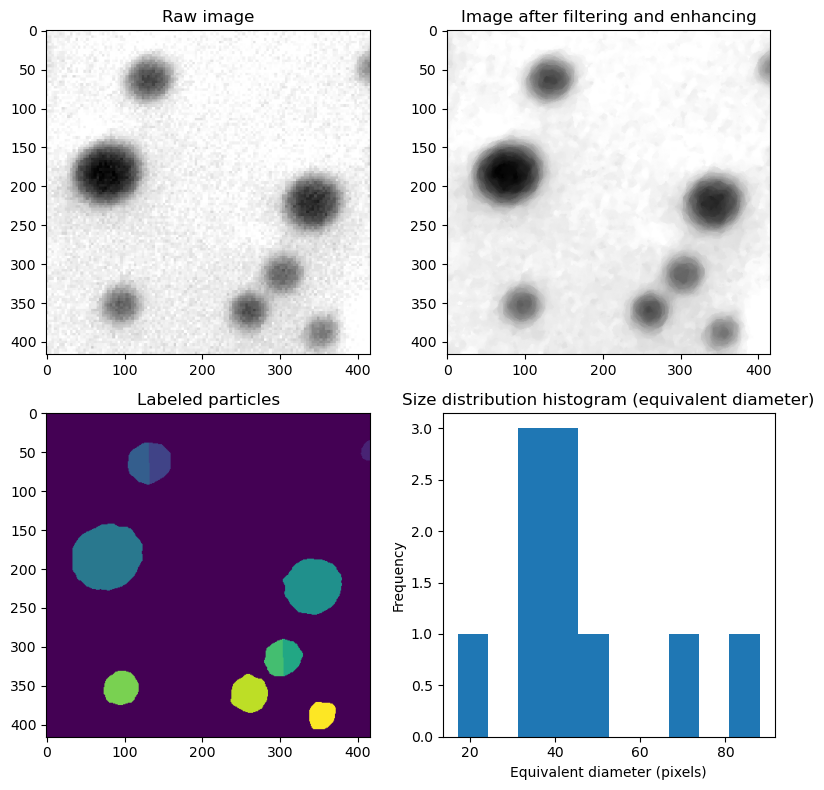

              area   perimeter  eccentricity   solidity  equivalent_diameter  \
count    10.000000   10.000000     10.000000  10.000000            10.000000   
mean   1896.500000  155.315956      0.599516   0.970951            45.056205   
std    1812.688871   65.735231      0.271657   0.009637            20.673043   
min     231.000000   63.798990      0.148974   0.957048            17.149879   
25%     933.500000  125.142397      0.382185   0.961515            34.468923   
50%    1163.500000  140.547727      0.651476   0.973874            38.489101   
75%    1741.000000  155.867532      0.830069   0.978019            47.060199   
max    6087.000000  292.835570      0.889504   0.981318            88.035272   

       intensity_min  intensity_max  intensity_mean  intensity_std  
count      10.000000      10.000000       10.000000      10.000000  
mean        0.309536       0.673842        0.486253       0.104669  
std         0.157064       0.002506        0.089426       0.046059  
min

In [2]:
# Task 1 processing: filtering, enhancement, segmentation, quantification
# HINTS for Task 1:
# 1. Filtering: Use filters.median() or filters.gaussian() from skimage.filters
#    Compare SNR before and after filtering to see improvement
# 2. Enhancement: Use exposure.equalize_adapthist() with clip_limit around 0.025
#    This will increase contrast without oversaturation
# 3. Segmentation: After Otsu thresholding, use scipy.ndimage.distance_transform_edt()
#    to find marker positions for Watershed
# 4. Regionprops: Pass intensity_image parameter to get min/max/mean intensity
#    Example: measure.regionprops(labels, intensity_image=enhanced_image)
# 5. Export: Use pd.DataFrame.to_csv() to save measurements

from skimage.segmentation import watershed
from scipy import ndimage as ndi
from skimage.feature import peak_local_max

def compute_snr(image: np.ndarray) -> float:
    signal = np.mean(image)
    noise = np.std(image)
    return float(signal / noise) if noise else np.inf

# SNR before filtering
SNR_beforefilter = compute_snr(raw_image)

# Filtering hint: Try median filter for salt-and-pepper noise
filtered_image = ndi.median_filter(raw_image, footprint=morphology.disk(5))
SNR_afterfilter = compute_snr(filtered_image) # SNR after filtering

print(f'Signal to noise ratio before filtering: {SNR_beforefilter}')
print(f'Signal to noise ratio after filtering: {SNR_afterfilter}')

# Enhancement hint: CLAHE improves local contrast
enhanced_image = exposure.equalize_adapthist(filtered_image, clip_limit=0.004)

# Segmentation hint: Use Otsu's threshold followed by watershed
threshold = filters.threshold_otsu(enhanced_image)
binary = enhanced_image < threshold
binary = morphology.remove_small_objects(binary, max_size=20)
binary = morphology.remove_small_holes(binary, max_size=20)

# Then use distance transform + watershed to separate particles
distance = ndi.distance_transform_edt(binary)
coords = peak_local_max(distance, footprint=np.ones((3, 3)), labels=binary)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)
labels = watershed(-distance, markers, mask=binary)

# Morphology hint: Extract area, perimeter, eccentricity, solidity, equivalent_diameter
# Store in a DataFrame, then save with measurements.to_csv()
properties = measure.regionprops(labels, intensity_image=enhanced_image)
proptable = measure.regionprops_table(labels, intensity_image=enhanced_image, properties=('area', 'perimeter', 'eccentricity', 'solidity', 'equivalent_diameter', 'intensity_min', 'intensity_max', 'intensity_mean', 'intensity_std'))
measurements = pd.DataFrame(proptable)
measurements.to_csv('classical_results.csv', index=False)

# Visualization hint: Create 2x2 subplot figure with:
# [Raw image] [Enhanced/Filtered]
# [Segmented labels] [Size distribution histogram]
# Use imshow() for images and hist() for distribution

fig, ax = plt.subplots(2, 2, figsize=(8,8))

ax[0, 0].imshow(raw_image, cmap='gray')
ax[0, 0].set_title('Raw image')

ax[0, 1].imshow(enhanced_image, cmap='gray')
ax[0, 1].set_title('Image after filtering and enhancing')

ax[1, 0].imshow(labels)
ax[1, 0].set_title('Labeled particles')

ax[1, 1].hist(proptable['equivalent_diameter'])
ax[1, 1].set_title('Size distribution histogram (equivalent diameter)')
ax[1, 1].set_xlabel('Equivalent diameter (pixels)')
ax[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print(measurements.describe())

## Task 2 · Machine Learning Approaches
- [ ] Extract hand-crafted features: edges (Canny or Sobel), blobs (LoG), textures (LBP or GLCM) to build a feature matrix with at least 10 descriptors per region.
- [ ] Perform feature selection using Random Forest importance or correlation analysis; retain the top 5-7 discriminative features.
- [ ] Supervised: label data into two or more classes (≥50 samples), train SVM and Random Forest, then report precision, recall, F1-score, and confusion matrices.
- [ ] Unsupervised: run k-Means (k ∈ {3, 5, 7}) and visualize using PCA or t-SNE; compute silhouette scores.
- [ ] Compare ML outputs with classical segmentation regarding particle counts, accuracy, and runtime; export to `ml_results.csv`.

In [3]:
# Task 2: feature extraction and ML pipelines
from skimage.feature import canny, local_binary_pattern
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# HINTS for Task 2:
# 1. Feature extraction: For each detected region, compute:
#    - Area, perimeter, equivalent diameter, eccentricity, solidity (from regionprops)
#    - Mean and std intensity (intensity-based features)
#    - Edge features: number of edges detected by Canny filter
#    - Texture: Local Binary Pattern variance
#    - Circularity = 4*pi*area / perimeter^2
#    - Total: 10+ features per region
#
# 2. Feature selection: Train a RandomForestClassifier and get feature_importances_
#    Keep top 5-7 features with highest importance scores
#    Hint: importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
#
# 3. Supervised ML:
#    - Split data into train/test (80/20)
#    - Scale features using StandardScaler()
#    - Train SVM with kernel='rbf' and Random Forest with n_estimators=100
#    - Compute F1-score: metrics.f1_score(y_true, y_pred)
#    - Create confusion matrix: metrics.confusion_matrix(y_true, y_pred)
#
# 4. Unsupervised ML:
#    - Run KMeans for k in [3, 5, 7]
#    - Compute silhouette_score(X_scaled, clusters) for each k
#    - Use PCA(n_components=2) to project to 2D for visualization
#    - Plot scatter with cluster labels as colors
#
# 5. Export: Save results to ml_results.csv with columns:
#    [Method, F1-Score, Precision, Recall, Silhouette_Score]

# TODO: assemble feature matrix and labels
# This function first finds all segmented regions from a series of images and then returns a list of properties of all regions.
def extract_features(imageseries):
    properties = {'area': [], 'perimeter': [], 'eccentricity': [], 'solidity': [], 'equivalent_diameter': [], 'intensity_mean': [], 'intensity_std': [], 'edges': [], 'texture': [], 'circularity': []}
    for image in imageseries:
        image = image[:,:,0]
        filtered_image = filters.median(image, footprint=morphology.disk(5))
        enhanced_image = exposure.equalize_adapthist(filtered_image, clip_limit=0.004)
        threshold = filters.threshold_otsu(enhanced_image)
        binary = enhanced_image < threshold
        binary = morphology.remove_small_objects(binary, max_size=20)
        binary = morphology.remove_small_holes(binary, max_size=20)
        distance = ndi.distance_transform_edt(binary)
        coords = peak_local_max(distance, footprint=np.ones((3, 3)), labels=binary)
        mask = np.zeros(distance.shape, dtype=bool)
        mask[tuple(coords.T)] = True
        markers, _ = ndi.label(mask)
        labels = watershed(-distance, markers, mask=binary)

        regions = measure.regionprops(labels, intensity_image=enhanced_image)
        region_proptable = measure.regionprops_table(labels, intensity_image=enhanced_image, properties=('area', 'perimeter', 'eccentricity', 'solidity', 'equivalent_diameter', 'intensity_mean', 'intensity_std'))
        for i, region in enumerate(regions):
            zoomed_in_img = image[region.bbox[0]:region.bbox[2], region.bbox[1]:region.bbox[3]]
            mask = region.image
        
            properties['area'].append(region_proptable['area'][i])
            properties['perimeter'].append(region_proptable['perimeter'][i])
            properties['eccentricity'].append(region_proptable['eccentricity'][i])
            properties['solidity'].append(region_proptable['solidity'][i])
            properties['equivalent_diameter'].append(region_proptable['equivalent_diameter'][i])
            properties['intensity_mean'].append(region_proptable['intensity_mean'][i])
            properties['intensity_std'].append(region_proptable['intensity_std'][i])
            properties['edges'].append(np.sum(canny(zoomed_in_img)) / region_proptable['area'][i])
            properties['texture'].append(np.var(local_binary_pattern(zoomed_in_img, P=8, R=1, method='uniform')))
            properties['circularity'].append(4*np.pi*region_proptable['area'][i]/region_proptable['perimeter'][i]**2 if region_proptable['perimeter'][i] > 0 else 0)

    return properties

imageseries = []
for i in range(50):
    imageseries.append(imread(str(sample_images[i])))

X = extract_features(imageseries)

features = pd.DataFrame(X)
labels = pd.Series(X)
features

,area,perimeter,eccentricity,solidity,equivalent_diameter,intensity_mean,intensity_std,edges,texture,circularity
0,231.0,63.798990,0.889504,0.958506,17.149879,0.614209,0.041091,0.251082,3.310805,0.713172
1,1167.0,139.840620,0.817218,0.978206,38.546991,0.463729,0.117300,0.254499,3.339791,0.749918
2,1160.0,141.254834,0.832661,0.969089,38.431210,0.463461,0.115047,0.270690,3.335191,0.730569
3,6087.0,292.835570,0.460563,0.981141,88.035272,0.305166,0.199769,0.250534,3.173021,0.892001
4,4179.0,243.279221,0.332185,0.976858,72.944280,0.384654,0.153587,0.281646,3.194335,0.887304
...,...,...,...,...,...,...,...,...,...,...
1029,1148.0,145.533009,0.811250,0.937908,38.231911,0.384564,0.116210,0.235192,3.193102,0.681128
1030,3817.0,230.551299,0.073643,0.979723,69.713380,0.284292,0.160220,0.246005,3.096470,0.902395
1031,973.0,115.254834,0.477859,0.973000,35.197473,0.481335,0.058665,0.230216,3.544168,0.920459
1032,922.0,112.083261,0.390586,0.972574,34.262616,0.491156,0.057882,0.225597,3.434621,0.922273


I will classify the particles based on how circular vs. elliptical they are (i.e. "good" vs. "bad" nanoparticles).

In [4]:
# TODO: perform feature selection and train supervised models
# Feature selection hint:
# rf_importance = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_importance.fit(X, y)
# top_features = np.argsort(rf_importance.feature_importances_)[-7:]
# svm_model = SVC(kernel='rbf')

property_names = ['area', 'perimeter', 'eccentricity', 'solidity', 'equivalent_diameter', 'intensity_mean', 'intensity_std', 'edges', 'texture', 'circularity']
classifier_labels = (features['eccentricity'] < np.mean(features['eccentricity'].values)) # if true or 1, this is circular. if false or 0, this is elliptical.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

rf_importance = RandomForestClassifier(n_estimators=100, random_state=42)
rf_importance.fit(X_scaled, classifier_labels)
top_features = np.flip(np.argsort(rf_importance.feature_importances_)[-7:])
top_features = [property_names[val] for i, val in enumerate(top_features)]
top_importances = np.flip(np.sort(rf_importance.feature_importances_)[-7:])

feature_importance = pd.DataFrame({
    'feature': top_features,
    'importance': top_importances
})

feature_importance

,feature,importance
0,eccentricity,0.565332
1,circularity,0.207840
2,area,0.074210
3,equivalent_diameter,0.057624
4,edges,0.024719
5,solidity,0.019325
6,perimeter,0.018587


As we would expect, the eccentricity and circularity of the nanoparticles are the most important features in determining how circular vs. elliptical a nanoparticle is.

,RandomForest,SVM
model,"(DecisionTreeClassifier(max_features='sqrt', r...",SVC()
precision,1.0,0.972222
recall,1.0,0.972222
f1_score,1.0,0.972222
confusion_matrix,"[[135, 0], [0, 72]]","[[133, 2], [2, 70]]"


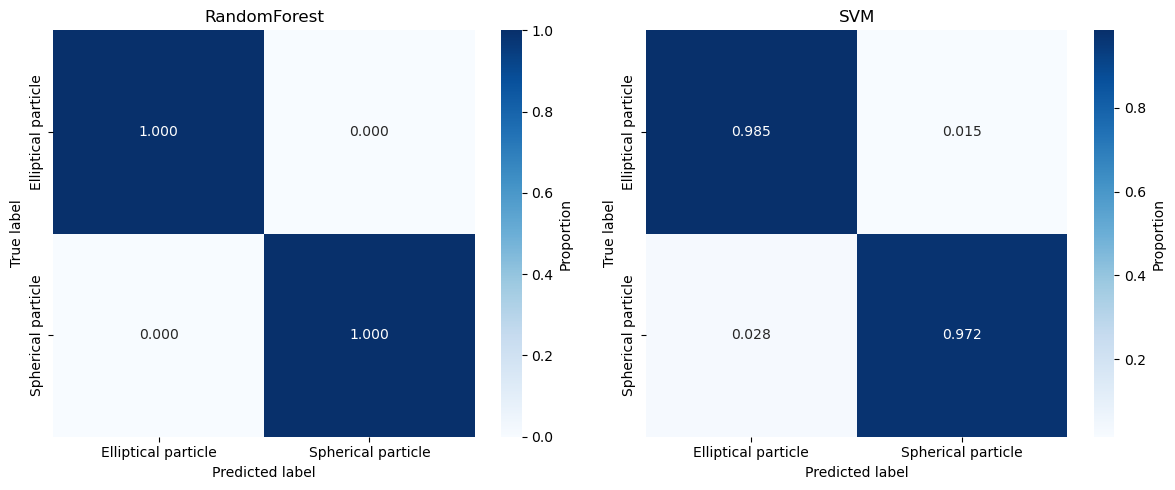

In [5]:
# TODO: evaluate models, generate confusion matrices, export results
import seaborn

X_tot = np.array([X['eccentricity'], X['circularity'], X['edges'], X['area'], X['equivalent_diameter'], X['perimeter'], X['intensity_std']])
X_tot = np.transpose(X_tot)
y = classifier_labels
X_train, X_test, y_train, y_test = train_test_split(X_tot, y, test_size=0.2, random_state=42, stratify=classifier_labels)

models = {'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42), 'SVM': SVC(kernel='rbf')}
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    f1 = metrics.f1_score(y_test, y_pred)
    confusion_matrix = metrics.confusion_matrix(y_test, y_pred)

    results[name] = {
        'model': model,
        'precision': metrics.precision_score(y_test, y_pred),
        'recall': metrics.recall_score(y_test, y_pred),
        'f1_score': metrics.f1_score(y_test, y_pred),
        'confusion_matrix': metrics.confusion_matrix(y_test, y_pred)
    }

ml_results = pd.DataFrame(results)
ml_results.to_csv('ml_results.csv', index=False)
display(ml_results)

# Confusion matrix visualization hint:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for i, (name, result) in enumerate(results.items()):
    cm = result['confusion_matrix']
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    seaborn.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
                   xticklabels=['Elliptical particle', 'Spherical particle'],
                   yticklabels=['Elliptical particle', 'Spherical particle'],
                   ax=axes[i], cbar_kws={'label': 'Proportion'})
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted label')
    axes[i].set_ylabel('True label')

plt.tight_layout()

C:\Users\wkddk\miniconda3\envs\ms465-2026\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\wkddk\miniconda3\envs\ms465-2026\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\wkddk\miniconda3\envs\ms465-2026\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Silhouette score for k = 3: 0.296
Silhouette score for k = 5: 0.277
Silhouette score for k = 7: 0.304


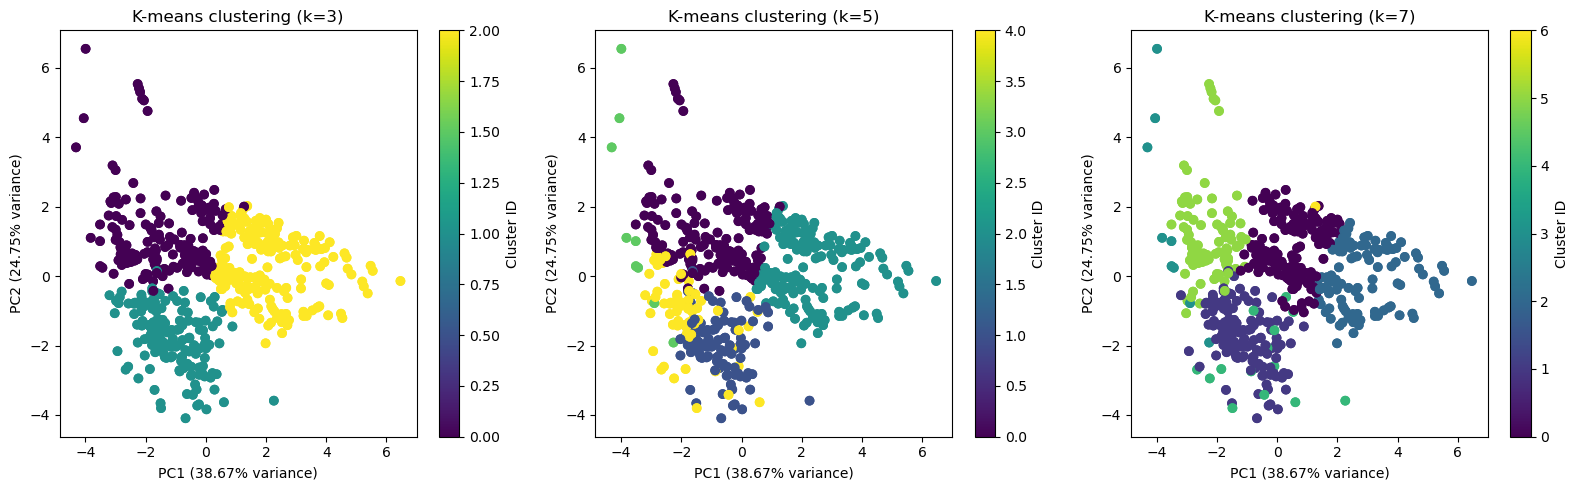

In [7]:
# TODO: run unsupervised clustering and visualize embeddings
# K-Means hint: clusters = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
# PCA visualization: X_pca = PCA(n_components=2).fit_transform(X_scaled)
#                   plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)

ks = [3, 5, 7]
silhouette_scores = []
labels = []
features_scaled = scaler.fit_transform(classifier_labels.values.reshape(-1,1))

for k in ks:
    clusters = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
    labels.append(clusters)
    silhouette_scores.append(silhouette_score(X_scaled, clusters))
    print(f'Silhouette score for k = {k}: {silhouette_score(X_scaled, clusters):.3f}')

pca = PCA(n_components=2)
features_pca = pca.fit_transform(X_scaled)

fig, axs = plt.subplots(1, 3, figsize=(16,5))

scatter1 = axs[0].scatter(features_pca[:,0], features_pca[:,1], c=labels[0])
axs[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
axs[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axs[0].set_title('K-means clustering (k=3)')
plt.colorbar(scatter1, ax=axs[0], label='Cluster ID')

scatter2 = axs[1].scatter(features_pca[:,0], features_pca[:,1], c=labels[1])
axs[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
axs[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axs[1].set_title('K-means clustering (k=5)')
plt.colorbar(scatter2, ax=axs[1], label='Cluster ID')

scatter3 = axs[2].scatter(features_pca[:,0], features_pca[:,1], c=labels[2])
axs[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
axs[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
axs[2].set_title('K-means clustering (k=7)')
plt.colorbar(scatter3, ax=axs[2], label='Cluster ID')

plt.tight_layout()

## Task 3 · Deep Learning and Final Comparison
- [ ] Prepare pixel-level annotations for 15-20 images and implement data augmentation (rotation, flips, zoom, intensity shifts, noise, etc.; 5+ variants).
- [ ] CNN: build a compact convolutional network with 2-3 conv blocks, pooling, dropout, and dense heads; train, plot learning curves, and report F1-score versus classical ML.
- [ ] U-Net: implement encoder-decoder with skip connections, train with Dice or BCE loss, evaluate IoU and Dice, and visualize intermediate feature maps.
- [ ] Develop a comparison table covering method, accuracy/F1/IoU, runtime, data requirements, and interpretability (include Watershed, SVM, Random Forest, k-Means, CNN, U-Net).
- [ ] Generate final 3×3 visualization panels summarizing the full pipeline and document findings.
- [ ] Author README.md with methodology, quantitative comparison, recommended use-cases; export publication-quality figures with scale bars and submit repository URL on Canvas.

In [ ]:
# Task 3: deep learning workflow templates
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# HINTS for Task 3:
# 1. Data preparation:
#    - Use ImageDataGenerator with augmentation parameters:
#      rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
#      zoom_range=0.2, fill_mode='reflect'
#    - Normalize pixel values to [0, 1]
#    - Use flow_from_directory() or flow() from keras preprocessing
#
# 2. CNN Architecture (simple but effective):
#    - Conv2D(32, 3x3) + BatchNorm + ReLU + MaxPool(2x2)
#    - Conv2D(64, 3x3) + BatchNorm + ReLU + MaxPool(2x2)
#    - Flatten + Dense(128) + Dropout(0.5) + Dense(num_classes)
#    - Compile with optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']
#    - Train with model.fit(train_dataset, validation_data=val_dataset, epochs=20)
#
# 3. U-Net Architecture (for segmentation):
#    - Encoder: Conv -> MaxPool (downsampling)
#    - Decoder: UpSampling -> Conv (upsampling)
#    - Skip connections: concatenate encoder features with decoder features
#    - Output: single channel with sigmoid activation (binary segmentation)
#    - Loss: keras.losses.BinaryCrossentropy() or Dice loss
#
# 4. Evaluation metrics:
#    - CNN: F1-score = 2 * (precision * recall) / (precision + recall)
#    - U-Net: IoU = intersection / union, Dice = 2 * intersection / (A + B)
#    - Hint: Use sklearn.metrics.f1_score, precision_score, recall_score
#
# 5. Visualization:
#    - Plot training curves: plt.plot(history.history['loss'], label='train')
#    - Show ground truth vs predictions side by side
#    - Display intermediate feature maps from encoder layers

# TODO: build data loaders with augmentation pipelines
train_dataset = None
val_dataset = None

# Data augmentation hint:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# datagen = ImageDataGenerator(
#     rotation_range=30,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     zoom_range=0.2,
#     fill_mode='reflect'
# )
# train_dataset = datagen.flow_from_directory('train_path', target_size=(416, 416))

# TODO: define CNN model
cnn_model = None

# CNN model hint:
# model = keras.Sequential([
#     layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(416, 416, 1)),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D(2),
#     layers.Conv2D(64, 3, activation='relu', padding='same'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D(2),
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(num_classes, activation='softmax')
# ])

# TODO: train CNN and plot metrics
cnn_history = None

# Training hint:
# cnn_history = cnn_model.fit(
#     train_dataset,
#     validation_data=val_dataset,
#     epochs=20,
#     callbacks=[keras.callbacks.EarlyStopping(patience=3)]
# )

# TODO: define U-Net architecture
unet_model = None

# U-Net hint: Build encoder (downsampling) then decoder (upsampling) with skip connections
# Encoder:  Conv -> ReLU -> MaxPool (4 levels)
# Decoder:  UpSampling -> Conv + concatenate from encoder
# Output:   Conv(1, 1x1, sigmoid) for binary segmentation

# TODO: train U-Net, compute IoU and Dice, visualize feature maps
# U-Net metrics hint:
# y_pred = unet_model.predict(X_test)
# iou = jaccard_score(y_test.flatten(), (y_pred > 0.5).flatten())
# dice = f1_score(y_test.flatten(), (y_pred > 0.5).flatten())

## Dataset: DOPAD (Dataset Of nanoPArticle Detection)

**Overview:**
- **272 original TEM images** at varying resolutions (~1.5M total particles)
- High-resolution nanoparticle detection annotations
- Diverse imaging environments and particle morphologies

**Note:** You do **not** need to use all 272 images. Using **100images** is sufficient for this assignment and will provide excellent statistical validation while keeping computational cost manageable.

**Download:** https://dopad.github.io/docs/download/

**Citation:** Qu et al. - For academic use, cite appropriately per repository guidelines.

## Deliverables Checklist
- [ ] Classical pipeline outputs (`classical_results.csv`, four-panel figure).
- [ ] ML analyses (`ml_results.csv`, confusion matrices, clustering visualizations).
- [ ] Deep learning artifacts (training curves, segmentation outputs, feature maps).
- [ ] Comparison table summarizing methods and metrics.
- [ ] Final 3×3 visualization collage.
- [ ] README.md documenting methodology, quantitative comparisons, and recommendations.
- [ ] Publication-quality figures with scale bars and repository submission.